In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:


# Load the dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
airpass = pd.read_csv(url)
airpass.head()


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [13]:
airpassenger = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
airpassenger.head()


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


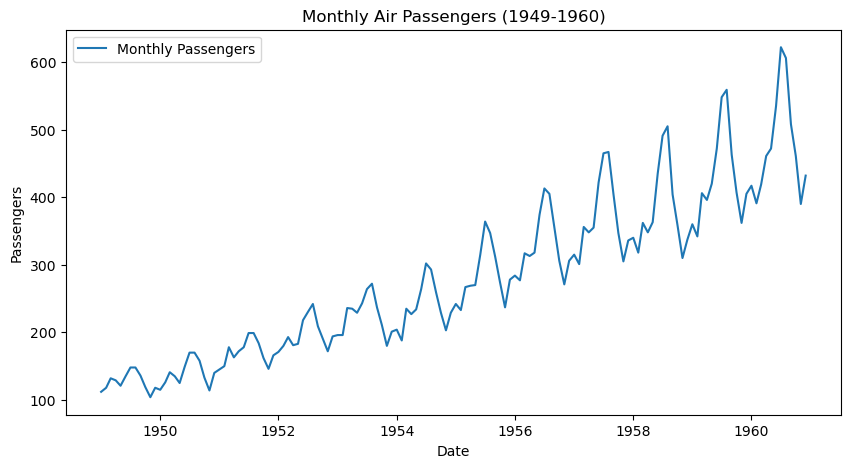

In [15]:
plt.figure(figsize=(10,5))
plt.plot(airpassenger, label='Monthly Passengers')
plt.title("Monthly Air Passengers (1949-1960)")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.show()


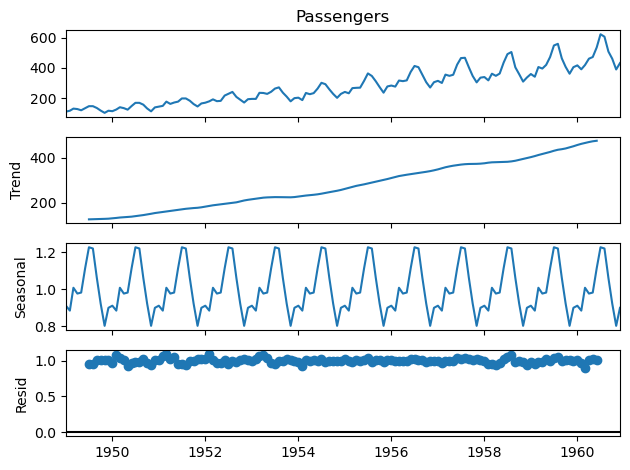

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(airpassenger['Passengers'], model='multiplicative')
decomposition.plot()
plt.show()


In [23]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(airpassenger['Passengers'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')


ADF Statistic: 0.8153688792060547
p-value: 0.9918802434376411


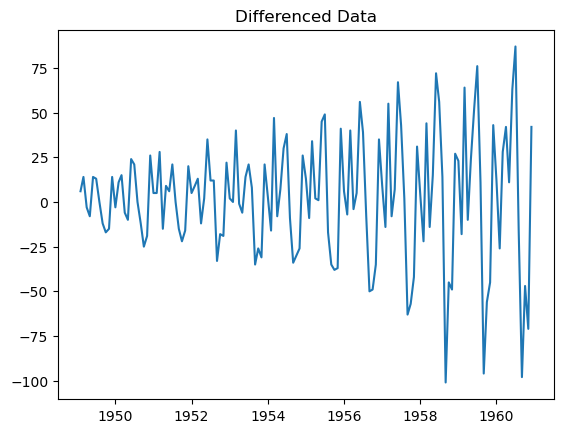

In [25]:
df_diff = airpassenger.diff().dropna()

plt.plot(df_diff)
plt.title("Differenced Data")
plt.show()


In [27]:
df_diff

,Passengers
Month,
1949-02-01,6.0
1949-03-01,14.0
1949-04-01,-3.0
1949-05-01,-8.0
1949-06-01,14.0
...,...
1960-08-01,-16.0
1960-09-01,-98.0
1960-10-01,-47.0


In [31]:


result = adfuller(df_diff['Passengers'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')



ADF Statistic: -2.829266824170004
p-value: 0.05421329028382491


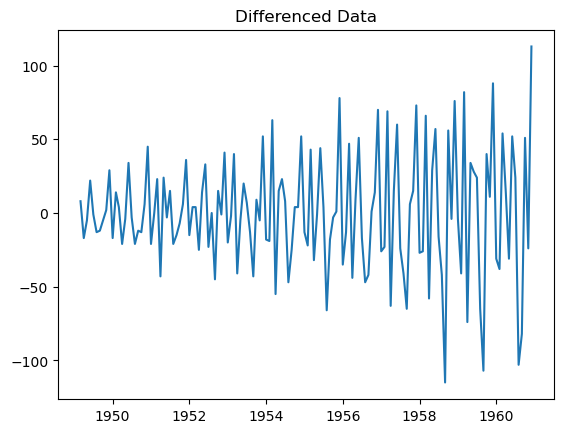

In [39]:
df_diff2 = airpassenger.diff().diff().dropna()
plt.plot(df_diff2)
plt.title("Differenced Data")
plt.show()

In [37]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_diff2['Passengers'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -16.38423154246853
p-value: 2.732891850014085e-29


In [43]:
!pip install pmdarima

   ---------------------------------------- 0.0/625.1 kB ? eta -:--:--
   --------------------------------- ------ 524.3/625.1 kB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 625.1/625.1 kB 1.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.7 MB 3.4 MB/s eta 0:00:01
   --------------- ------------------------ 1.0/2.7 MB 2.4 MB/s eta 0:00:01
   ------------------- -------------------- 1.3/2.7 MB 2.3 MB/s eta 0:00:01
   --------------------------- ------------ 1.8/2.7 MB 2.1 MB/s eta 0:00:01
   ------------------------------- -------- 2.1/2.7 MB 2.1 MB/s eta 0:00:01
   -------------------------------------- - 2.6/2.7 MB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 1.8 MB/s eta 0:00:00


In [45]:
from pmdarima import auto_arima

stepwise_model = auto_arima(df_diff2, start_p=1, start_q=1,
                            test='adf',
                            seasonal=True,
                            m=12,
                            trace=True,
                            error_action='ignore',
                            suppress_warnings=True,
                            stepwise=True)

print(stepwise_model.summary())


Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,1,1)[12] intercept   : AIC=inf, Time=4.19 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1151.749, Time=0.12 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1081.078, Time=0.14 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=0.28 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1149.749, Time=0.10 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=1080.172, Time=0.05 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=1081.216, Time=0.09 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=1082.590, Time=0.26 sec
 ARIMA(2,0,0)(0,1,0)[12] intercept   : AIC=1065.616, Time=0.09 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=1064.615, Time=0.13 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=1064.592, Time=0.44 sec
 ARIMA(2,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=1.11 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : AIC=1065.071, Time=0.39 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=1082.556, Time=0.23 sec
 ARIMA(3,0,0)(2,1,0)[12] intercept

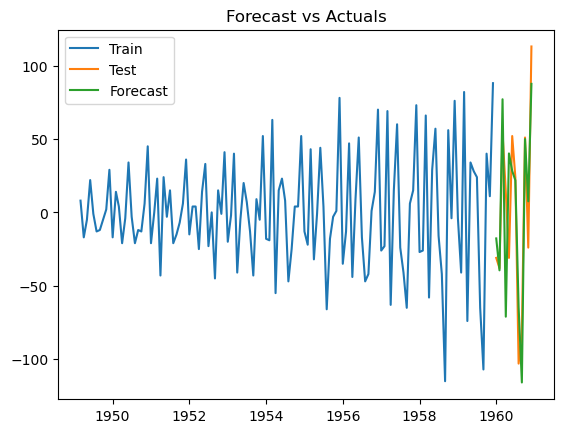

In [47]:
train = df_diff2[:'1959']
test = df_diff2['1960':]

stepwise_model.fit(train)

forecast = stepwise_model.predict(n_periods=12)
forecast = pd.DataFrame(forecast, index=test.index, columns=['Prediction'])

plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.title("Forecast vs Actuals")
plt.show()